## Introduction

This project analyzes COVID-19 infection dynamics using the SIR model.

We estimate the infection rate (β) and recovery rate (γ)
by fitting the model to real epidemic data.

## Model

We use the SIR model to describe the spread of an infectious disease.

The population is divided into three compartments:

- **S (Susceptible)**: individuals who can be infected  
- **I (Infected)**: currently infected individuals  
- **R (Recovered)**: individuals who have recovered and gained immunity  

The total population is

N = S + I + R

The dynamics are described by the following differential equations:

$\frac{dS}{dt} = -\beta S I / N$  

$\frac{dI}{dt} = \beta S I / N - \gamma I$  

$\frac{dR}{dt} = \gamma I$  

where

- **β** : infection rate  
- **γ** : recovery rate  

The basic reproduction number is given by

R₀ = β / γ


## Data
COVID-19 data is taken from the Our World in Data dataset.

Estimated beta: 0.3
Estimated gamma: 0.1
Estimated R0: 2.9999999999999996


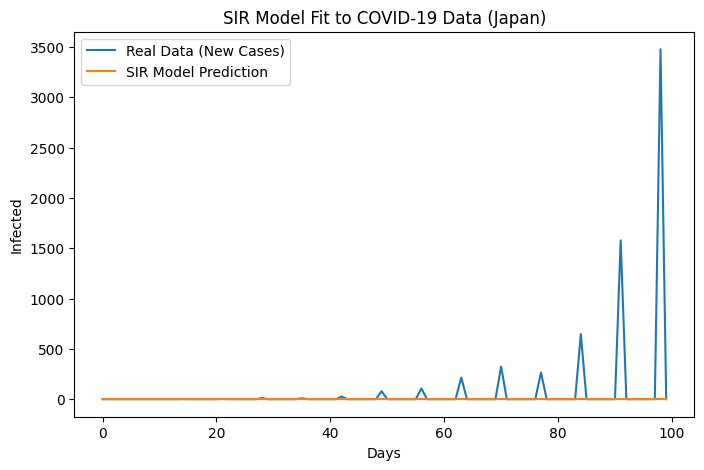

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import minimize
import matplotlib.pyplot as plt

df = pd.read_csv("owid-covid-data.csv")

japan = df[df["location"] == "Japan"].copy()
japan = japan[["date", "new_cases", "total_cases", "population"]]

japan["new_cases"] = japan["new_cases"].fillna(0)
japan["total_cases"] = japan["total_cases"].fillna(0)

japan = japan.iloc[:100]

N = japan["population"].iloc[0]

I_data = japan["new_cases"].values

R_data = japan["total_cases"].values * 0.2

S_data = N - I_data - R_data

S0, I0, R0 = S_data[0], I_data[0], R_data[0]


def sir_model(y, t, beta, gamma):
 S, I, R = y
 N = S + I + R

 dSdt = -beta * S * I / N
 dIdt = beta * S * I / N - gamma * I
 dRdt = gamma * I

 return [dSdt, dIdt, dRdt]

def run_sir(S0, I0, R0, beta, gamma, days):
 t = np.linspace(0, days, days)
 y0 = [S0, I0, R0]
 result = odeint(sir_model, y0, t, args=(beta, gamma))
 return t, result

def loss(params, infected_data, S0, I0, R0):
 beta, gamma = params
 t, result = run_sir(S0, I0, R0, beta, gamma, len(infected_data))
 I_pred = result[:,1]
 return np.mean((I_pred - infected_data)**2)

res = minimize(
    loss,
    [0.3, 0.1],
    args=(I_data, S0, I0, R0),
    bounds=[(0,1),(0,1)]
)

beta_opt, gamma_opt = res.x

print("Estimated beta:", beta_opt)
print("Estimated gamma:", gamma_opt)

R0_est = beta_opt / gamma_opt
print("Estimated R0:", R0_est)


t, result = run_sir(S0, I0, R0, beta_opt, gamma_opt, len(I_data))


plt.figure(figsize=(8,5))

plt.plot(I_data, label="Real Data (New Cases)")
plt.plot(result[:,1], label="SIR Model Prediction")

plt.xlabel("Days")
plt.ylabel("Infected")
plt.title("SIR Model Fit to COVID-19 Data (Japan)")
plt.legend()

plt.show()

## Discussion
The SIR model reproduces the initial growth of infections,
although deviations appear due to behavioral changes and policies.